In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression

In [ ]:
# Load air quality dataset
air_quality_file = '/content/global_air_quality_data_10000.csv'
mortality_file = '/content/death-rates-from-air-pollution.csv'

air_quality = pd.read_csv(air_quality_file)
mortality = pd.read_csv(mortality_file)


In [ ]:
air_quality.head(5)


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


In [ ]:
mortality.head(5)

,Country,Code,Year,"Air pollution (total) (deaths per 100,000)","Indoor air pollution (deaths per 100,000)","Outdoor particulate matter (deaths per 100,000)","Outdoor ozone pollution (deaths per 100,000)"
0,Afghanistan,AFG,1990,299.477309,250.362910,46.446589,5.616442
1,Afghanistan,AFG,1991,291.277967,242.575125,46.033841,5.603960
2,Afghanistan,AFG,1992,278.963056,232.043878,44.243766,5.611822
3,Afghanistan,AFG,1993,278.790815,231.648134,44.440148,5.655266
4,Afghanistan,AFG,1994,287.162923,238.837177,45.594328,5.718922


In [ ]:
air_quality.shape

(10000, 12)

In [ ]:
mortality.shape

(6468, 7)

# Data Preprocessing & Merging

In [ ]:
# This will only keep rows where the 'Country' column exists in both datasets
combined_dataset = pd.merge(air_quality, mortality, on='Country', how='inner')

In [ ]:
# Save the combined dataset to a CSV file (optional)
combined_dataset.to_csv("combined_dataset.csv", index=False)

In [ ]:
# Print the first few rows of the combined dataset
print(combined_dataset.head())

      City   Country        Date  PM2.5   PM10    NO2    SO2    CO     O3  \
0  Bangkok  Thailand  2023-03-19  86.57  25.19  99.88  30.63  4.46  36.29   
1  Bangkok  Thailand  2023-03-19  86.57  25.19  99.88  30.63  4.46  36.29   
2  Bangkok  Thailand  2023-03-19  86.57  25.19  99.88  30.63  4.46  36.29   
3  Bangkok  Thailand  2023-03-19  86.57  25.19  99.88  30.63  4.46  36.29   
4  Bangkok  Thailand  2023-03-19  86.57  25.19  99.88  30.63  4.46  36.29   

   Temperature  Humidity  Wind Speed Code  Year  \
0        17.67     59.35       13.76  THA  1990   
1        17.67     59.35       13.76  THA  1991   
2        17.67     59.35       13.76  THA  1992   
3        17.67     59.35       13.76  THA  1993   
4        17.67     59.35       13.76  THA  1994   

   Air pollution (total) (deaths per 100,000)  \
0                                   80.867260   
1                                   79.591860   
2                                   78.509881   
3                                 

In [ ]:
combined_dataset.shape

(224812, 18)

In [ ]:
combined_dataset.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,Year,"Air pollution (total) (deaths per 100,000)","Indoor air pollution (deaths per 100,000)","Outdoor particulate matter (deaths per 100,000)","Outdoor ozone pollution (deaths per 100,000)"
count,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000,224812.000000
mean,77.312271,104.527772,52.146457,25.320352,5.042532,106.215569,14.872708,55.094556,10.257295,2003.500000,59.012504,16.389357,39.259721,5.062588
std,41.871490,55.150769,27.353495,14.113790,2.855063,55.064122,14.378414,26.039005,5.640367,8.077765,45.986756,27.693225,25.648228,6.599212
min,5.020000,10.000000,5.010000,1.000000,0.100000,10.040000,-10.000000,10.010000,0.500000,1990.000000,10.586440,0.015176,9.110733,0.275715
25%,40.890000,56.800000,28.300000,13.200000,2.560000,58.380000,2.330000,32.460000,5.310000,1996.750000,22.602876,0.239876,20.324084,1.999991
50%,77.610000,104.250000,52.320000,25.370000,5.060000,107.010000,14.750000,55.070000,10.280000,2003.500000,46.080051,1.568439,29.125944,2.876634
75%,113.130000,152.680000,75.720000,37.540000,7.470000,153.990000,27.100000,77.570000,15.130000,2010.250000,78.666176,19.888229,55.458729,4.369386
max,149.980000,200.000000,100.000000,49.990000,10.000000,200.000000,40.000000,99.970000,20.000000,2017.000000,211.376738,140.873078,119.470771,35.265966


# Visualizations

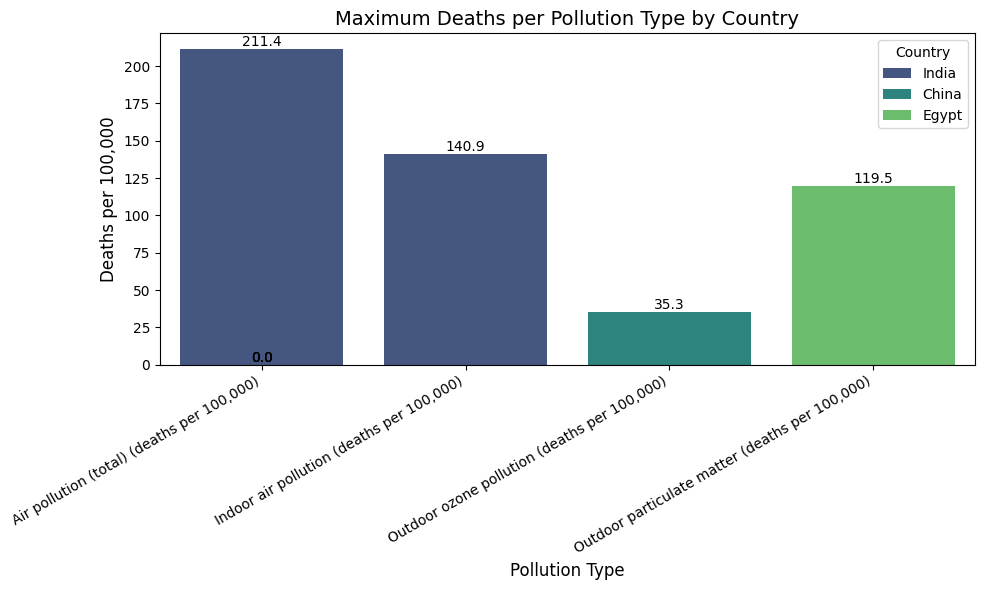

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the combined dataset (update the file path as needed)
combined_dataset = pd.read_csv("combined_dataset.csv")

# Select relevant columns for deaths due to air pollution
pollution_deaths = [
    "Air pollution (total) (deaths per 100,000)",
    "Indoor air pollution (deaths per 100,000)",
    "Outdoor particulate matter (deaths per 100,000)",
    "Outdoor ozone pollution (deaths per 100,000)"
]

# Melt the dataset to analyze deaths by pollution type
melted_df = combined_dataset.melt(
    id_vars=["Country"],
    value_vars=pollution_deaths,
    var_name="Pollution Type",
    value_name="Deaths per 100,000"
)

# Find the country with the most deaths for each pollution type
result = melted_df.loc[melted_df.groupby(["Pollution Type"])["Deaths per 100,000"].idxmax()]

# Plot the bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=result,
    x="Pollution Type",
    y="Deaths per 100,000",
    hue="Country",
    dodge=False,  # Avoid grouped bars
    palette="viridis"
)

# Add labels on top of each bar
for bar in barplot.patches:
    bar_height = bar.get_height()  # Get the height of the bar
    barplot.annotate(
        format(bar_height, ".1f"),  # Format the height with one decimal point
        (bar.get_x() + bar.get_width() / 2, bar_height),  # Place at the top center of the bar
        ha="center", va="bottom", fontsize=10, color="black"
    )

# Add chart details
plt.title("Maximum Deaths per Pollution Type by Country", fontsize=14)
plt.xlabel("Pollution Type", fontsize=12)
plt.ylabel("Deaths per 100,000", fontsize=12)
plt.xticks(rotation=30, ha="right")  # Rotate x-axis labels for better readability
plt.legend(title="Country", loc="upper right", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Calculate Pearson's correlation matrix
correlation_matrix = combined_dataset[['Air pollution (total) (deaths per 100,000)',
                                'Indoor air pollution (deaths per 100,000)',
                                'Outdoor particulate matter (deaths per 100,000)',
                                'Outdoor ozone pollution (deaths per 100,000)',
                                'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind Speed']].corr()

print(correlation_matrix)

                                                 Air pollution (total) (deaths per 100,000)  \
Air pollution (total) (deaths per 100,000)                                         1.000000   
Indoor air pollution (deaths per 100,000)                                          0.840956   
Outdoor particulate matter (deaths per 100,000)                                    0.774214   
Outdoor ozone pollution (deaths per 100,000)                                       0.800364   
PM2.5                                                                              0.011409   
PM10                                                                              -0.000592   
NO2                                                                               -0.004160   
SO2                                                                               -0.011543   
CO                                                                                 0.015543   
O3                                                

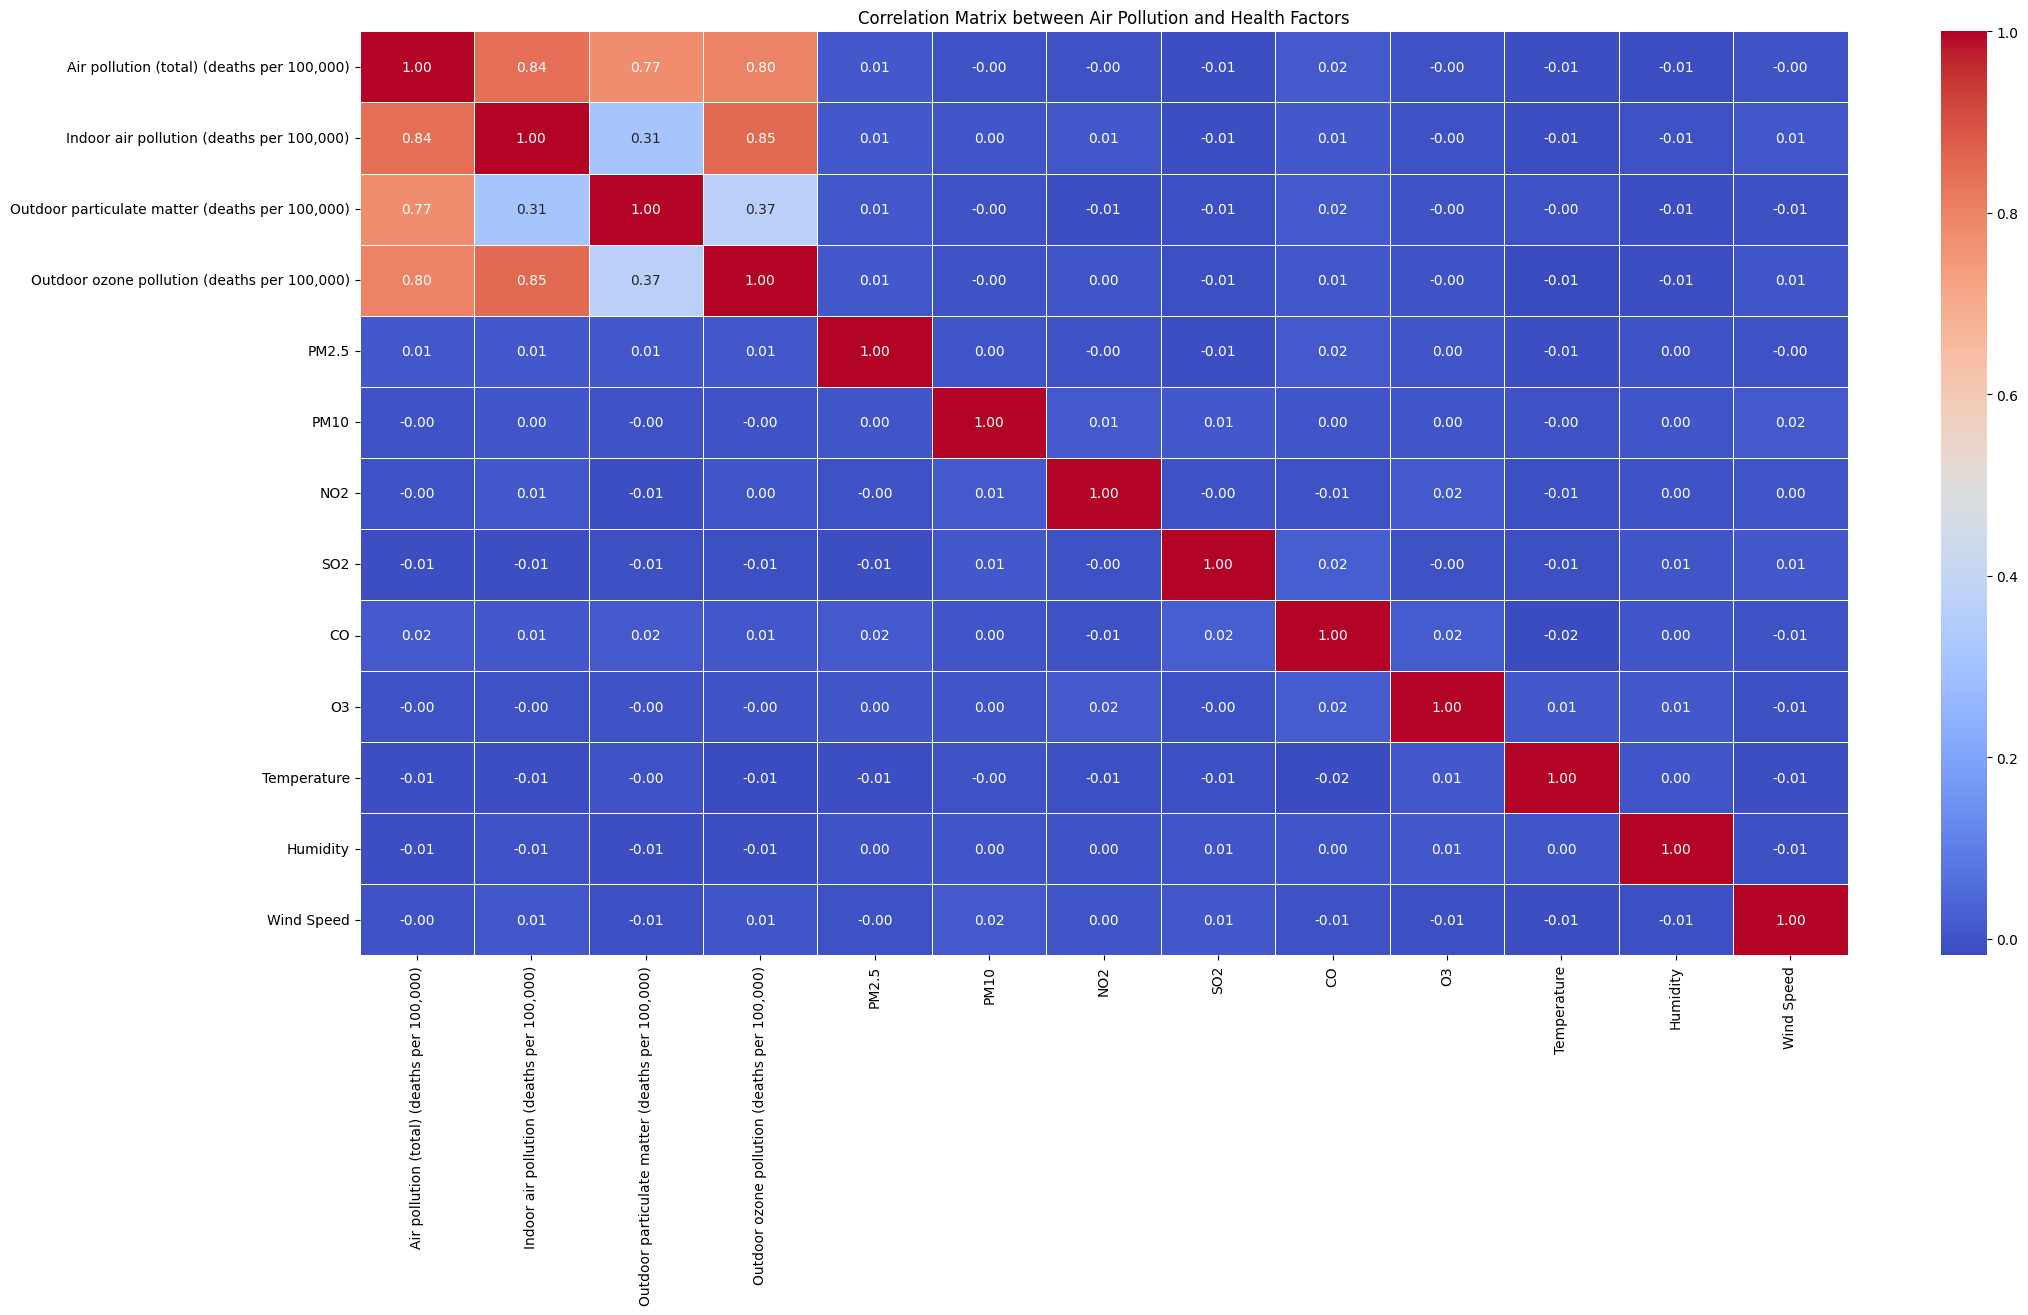

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of the correlation matrix
plt.figure(figsize=(24, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix between Air Pollution and Health Factors')
plt.show()

# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Select features and target
X = combined_dataset[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]  # Features
y = combined_dataset['Air pollution (total) (deaths per 100,000)']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 2099.5911272923377


# Prediction and Modeling
# Correlation Analysis for Predictive Modeling:
You can use correlation analysis to identify important variables for predictive modeling. For example, build a model to predict pollution levels based on other environmental factors (e.g., temperature, humidity, wind speed).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Example of predicting Air Pollution (Total Deaths per 100,000) based on other features
X = combined_dataset[['Temperature', 'Humidity', 'Wind Speed', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
y = combined_dataset['Air pollution (total) (deaths per 100,000)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print(f'Model Accuracy: {model.score(X_test, y_test)}')


Model Accuracy: 0.0007172407668794012


<ipython-input-18-cc5525297096>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gas_columns, y=correlations_air_pollution, ax=axes[0, 0], palette="coolwarm")
<ipython-input-18-cc5525297096>:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(gas_columns, rotation=45)
<ipython-input-18-cc5525297096>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gas_columns, y=correlations_indoor_pollution, ax=axes[0, 1], palette="coolwarm")
<ipython-input-18-cc5525297096>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

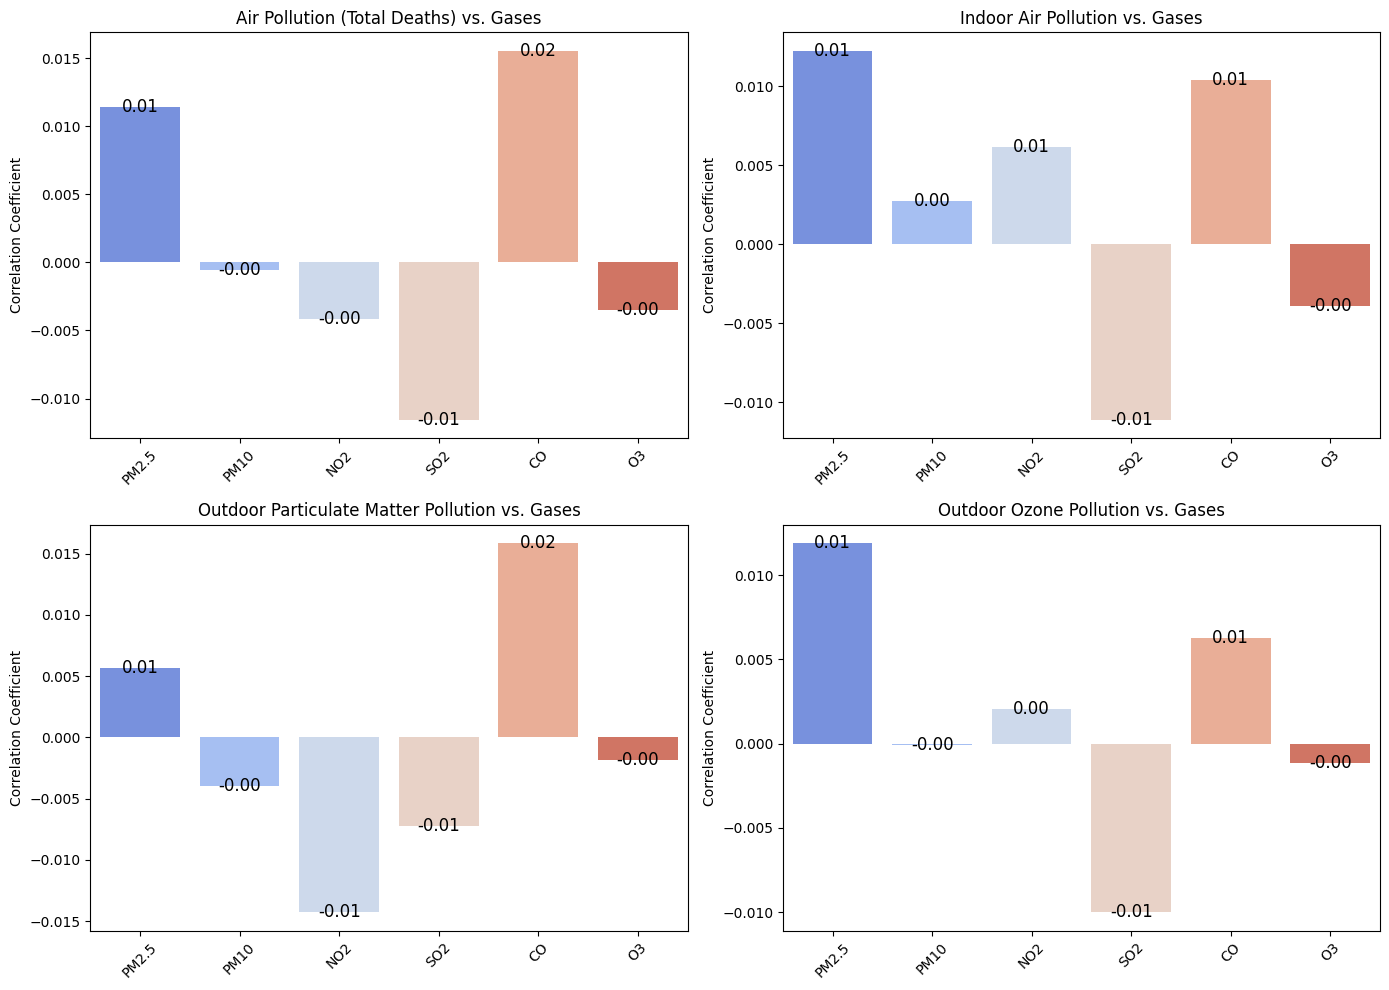

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a larger figure to hold multiple graphs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 grid of subplots

# Set the colors for different gases
gas_columns = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

# Calculate correlations between gases and pollution types
correlations_air_pollution = combined_dataset[gas_columns].corrwith(combined_dataset['Air pollution (total) (deaths per 100,000)'])
correlations_indoor_pollution = combined_dataset[gas_columns].corrwith(combined_dataset['Indoor air pollution (deaths per 100,000)'])
correlations_outdoor_particulate_pollution = combined_dataset[gas_columns].corrwith(combined_dataset['Outdoor particulate matter (deaths per 100,000)'])
correlations_outdoor_ozone_pollution = combined_dataset[gas_columns].corrwith(combined_dataset['Outdoor ozone pollution (deaths per 100,000)'])

# Plotting for each pollution type
sns.barplot(x=gas_columns, y=correlations_air_pollution, ax=axes[0, 0], palette="coolwarm")
axes[0, 0].set_title('Air Pollution (Total Deaths) vs. Gases')
axes[0, 0].set_ylabel('Correlation Coefficient')
axes[0, 0].set_xticklabels(gas_columns, rotation=45)
for i, v in enumerate(correlations_air_pollution):
    axes[0, 0].text(i, v, f'{v:.2f}', ha='center', color='black', fontsize=12, verticalalignment='center')

sns.barplot(x=gas_columns, y=correlations_indoor_pollution, ax=axes[0, 1], palette="coolwarm")
axes[0, 1].set_title('Indoor Air Pollution vs. Gases')
axes[0, 1].set_ylabel('Correlation Coefficient')
axes[0, 1].set_xticklabels(gas_columns, rotation=45)
for i, v in enumerate(correlations_indoor_pollution):
    axes[0, 1].text(i, v, f'{v:.2f}', ha='center', color='black', fontsize=12, verticalalignment='center')

sns.barplot(x=gas_columns, y=correlations_outdoor_particulate_pollution, ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set_title('Outdoor Particulate Matter Pollution vs. Gases')
axes[1, 0].set_ylabel('Correlation Coefficient')
axes[1, 0].set_xticklabels(gas_columns, rotation=45)
for i, v in enumerate(correlations_outdoor_particulate_pollution):
    axes[1, 0].text(i, v, f'{v:.2f}', ha='center', color='black', fontsize=12, verticalalignment='center')

sns.barplot(x=gas_columns, y=correlations_outdoor_ozone_pollution, ax=axes[1, 1], palette="coolwarm")
axes[1, 1].set_title('Outdoor Ozone Pollution vs. Gases')
axes[1, 1].set_ylabel('Correlation Coefficient')
axes[1, 1].set_xticklabels(gas_columns, rotation=45)
for i, v in enumerate(correlations_outdoor_ozone_pollution):
    axes[1, 1].text(i, v, f'{v:.2f}', ha='center', color='black', fontsize=12, verticalalignment='center')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


<ipython-input-19-bd99d6f3d034>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pollution Type', y='Value', data=plot_data, palette='coolwarm')


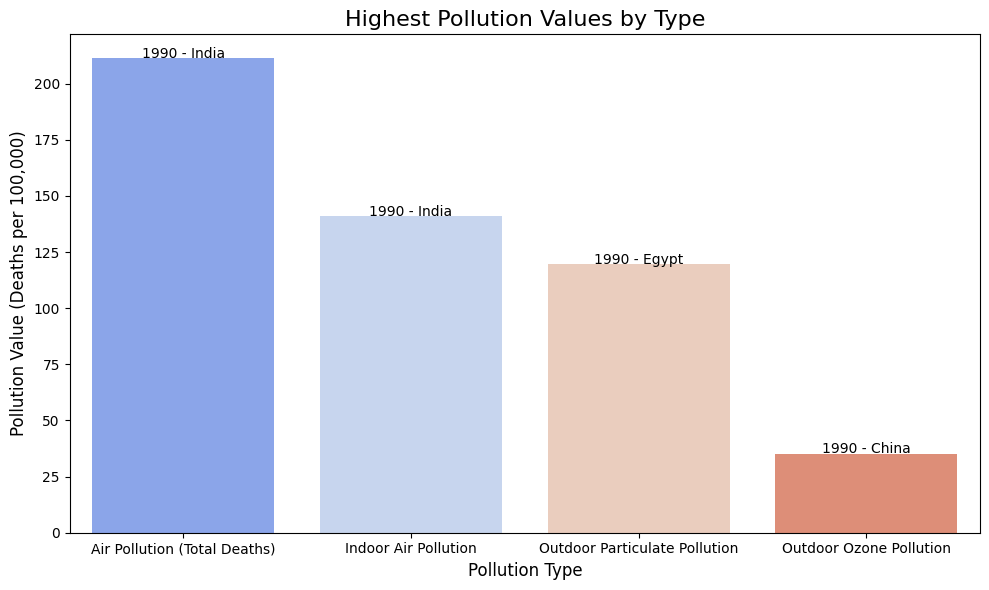

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Find the year and country with the highest values for each type of pollution
highest_air_pollution = combined_dataset.loc[combined_dataset['Air pollution (total) (deaths per 100,000)'].idxmax()]
highest_indoor_pollution = combined_dataset.loc[combined_dataset['Indoor air pollution (deaths per 100,000)'].idxmax()]
highest_outdoor_particulate_pollution = combined_dataset.loc[combined_dataset['Outdoor particulate matter (deaths per 100,000)'].idxmax()]
highest_outdoor_ozone_pollution = combined_dataset.loc[combined_dataset['Outdoor ozone pollution (deaths per 100,000)'].idxmax()]

# Extract the country and year for each type of pollution
highest_air_pollution_data = (highest_air_pollution['Year'], highest_air_pollution['Country'], highest_air_pollution['Air pollution (total) (deaths per 100,000)'])
highest_indoor_pollution_data = (highest_indoor_pollution['Year'], highest_indoor_pollution['Country'], highest_indoor_pollution['Indoor air pollution (deaths per 100,000)'])
highest_outdoor_particulate_data = (highest_outdoor_particulate_pollution['Year'], highest_outdoor_particulate_pollution['Country'], highest_outdoor_particulate_pollution['Outdoor particulate matter (deaths per 100,000)'])
highest_outdoor_ozone_data = (highest_outdoor_ozone_pollution['Year'], highest_outdoor_ozone_pollution['Country'], highest_outdoor_ozone_pollution['Outdoor ozone pollution (deaths per 100,000)'])

# Prepare data for plotting
pollution_types = ['Air Pollution (Total Deaths)', 'Indoor Air Pollution', 'Outdoor Particulate Pollution', 'Outdoor Ozone Pollution']
values = [
    highest_air_pollution_data[2],
    highest_indoor_pollution_data[2],
    highest_outdoor_particulate_data[2],
    highest_outdoor_ozone_data[2]
]
years = [highest_air_pollution_data[0], highest_indoor_pollution_data[0], highest_outdoor_particulate_data[0], highest_outdoor_ozone_data[0]]
countries = [highest_air_pollution_data[1], highest_indoor_pollution_data[1], highest_outdoor_particulate_data[1], highest_outdoor_ozone_data[1]]

# Create a DataFrame for plotting
plot_data = {
    'Pollution Type': pollution_types,
    'Value': values,
    'Year': years,
    'Country': countries
}

# Plotting
plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x='Pollution Type', y='Value', data=plot_data, palette='coolwarm')

# Add titles and labels
plt.title('Highest Pollution Values by Type', fontsize=16)
plt.xlabel('Pollution Type', fontsize=12)
plt.ylabel('Pollution Value (Deaths per 100,000)', fontsize=12)

# Annotate the bars with year and country information
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f'{years[i]} - {countries[i]}', ha='center', fontsize=10, color='black')

# Adjust layout
plt.tight_layout()
plt.show()


# Trend Analysis-Yearly Trends:

# Plot the yearly trend for each type of pollution to see if there are any patterns (increasing or decreasing trends).

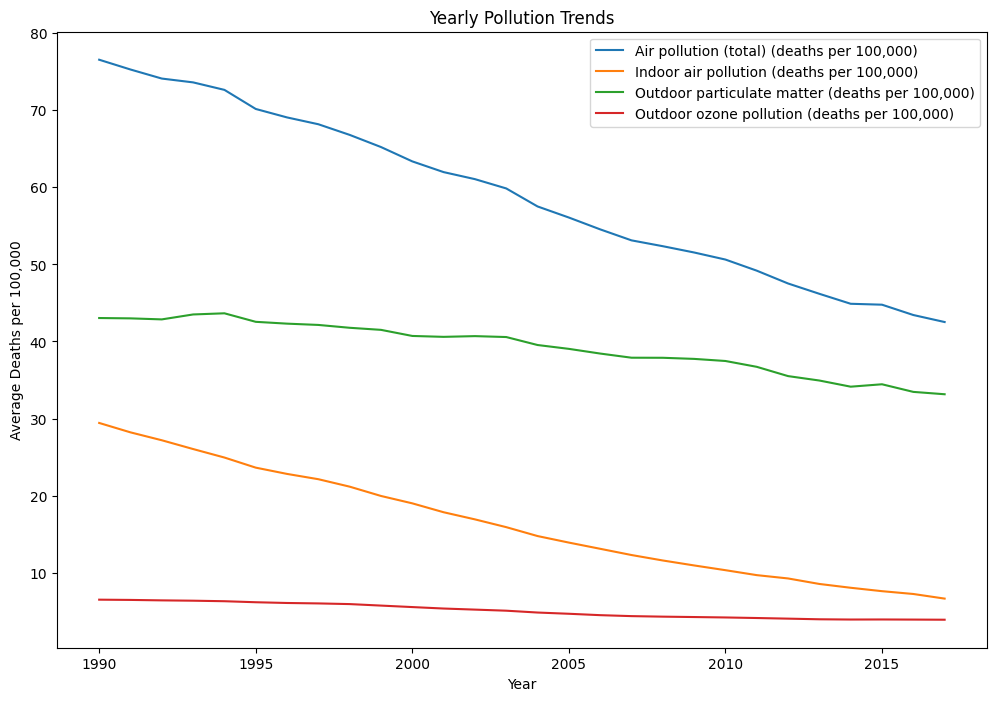

In [ ]:
combined_dataset.groupby('Year')[['Air pollution (total) (deaths per 100,000)', 'Indoor air pollution (deaths per 100,000)', 'Outdoor particulate matter (deaths per 100,000)', 'Outdoor ozone pollution (deaths per 100,000)']].mean().plot(figsize=(12, 8))
plt.title('Yearly Pollution Trends')
plt.ylabel('Average Deaths per 100,000')
plt.show()


# Country-specific Trends:

Analyze the pollution trend for specific countries over time.
python
Copy code


<Axes: xlabel='Year'>

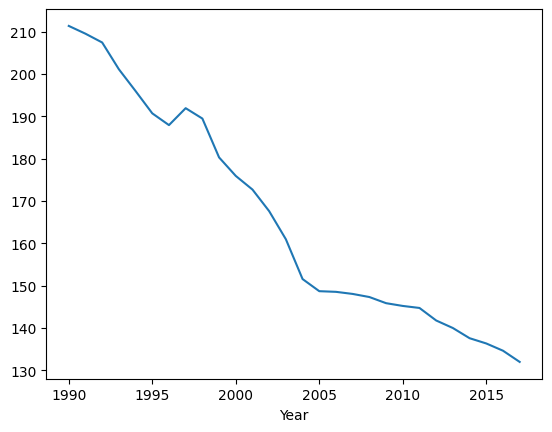

In [ ]:
country_data = combined_dataset[combined_dataset['Country'] == 'India']  # Example for India
country_data.groupby('Year')['Air pollution (total) (deaths per 100,000)'].mean().plot()


# Comparative Analysis
Compare Pollution Levels Across Countries:

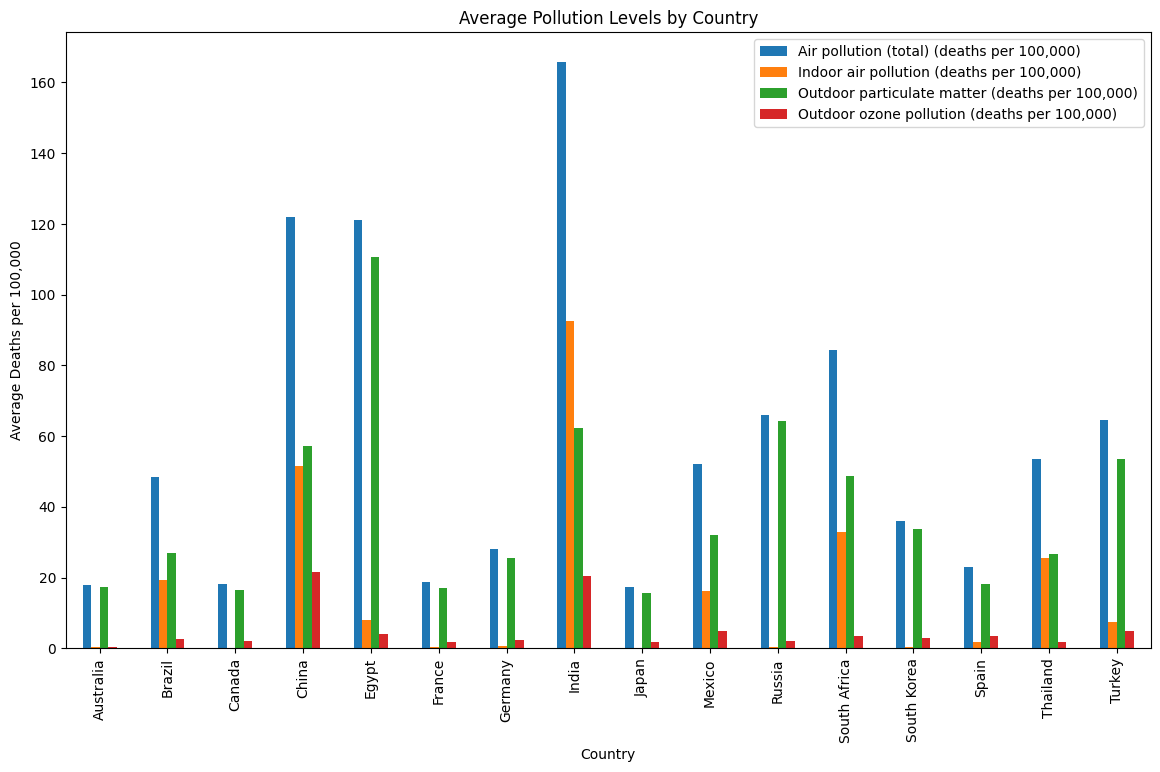

In [ ]:
country_avg_pollution = combined_dataset.groupby('Country')[['Air pollution (total) (deaths per 100,000)', 'Indoor air pollution (deaths per 100,000)', 'Outdoor particulate matter (deaths per 100,000)', 'Outdoor ozone pollution (deaths per 100,000)']].mean()
country_avg_pollution.plot(kind='bar', figsize=(14, 8))
plt.title('Average Pollution Levels by Country')
plt.ylabel('Average Deaths per 100,000')
plt.show()


### Summary and Conclusion of Dataset Analysis:

#### **Summary:**
1. **Data Overview**:
   - Combined datasets analyzed: Global air quality metrics and death rates from air pollution.
   - Features include air quality indicators (e.g., PM2.5, PM10, NO2) and pollution-related death rates.

2. **Visualization Insights**:
   - **Total Air Pollution Deaths**: India has the highest rate (211.4 deaths per 100,000), indicating severe pollution challenges from industrial and vehicular sources.
   - **Indoor Air Pollution**: India also leads with a death rate of 140.9 per 100,000, reflecting reliance on solid fuels in rural areas.
   - **Outdoor Ozone Pollution**: China tops this category (35.3 deaths per 100,000), likely due to industrial emissions.
   - **Outdoor Particulate Pollution**: Egypt experiences the highest rate (119.5 deaths per 100,000), driven by urban pollution and desert dust.

3. **Correlation Analysis**:
   - Weak correlations between air pollution deaths and gases such as PM2.5, PM10, and others.
   - Highlights complex interactions among factors affecting air quality and health outcomes.

4. **Machine Learning Results**:
   - A linear regression model used to predict total air pollution deaths had a low accuracy (R² ≈ 0.0007), suggesting non-linear relationships or omitted factors.

5. **Trends**:
   - Yearly analysis showed gradual changes, with India exhibiting consistent high pollution-related death rates.

---

#### **Conclusion:**
- **Key Insights**:
  - India faces significant health challenges from both indoor and total air pollution, demanding urgent interventions like cleaner energy sources and stricter regulations.
  - China and Egypt highlight regional-specific issues, such as ozone pollution and particulate matter, requiring tailored solutions.

- **Actionable Recommendations**:
  - Promote clean cooking fuels and improve ventilation in India to mitigate indoor air pollution deaths.
  - Enhance urban planning and emissions control in China to address ozone pollution.
  - Deploy measures in Egypt to combat particulate matter, such as afforestation and urban green spaces.

- **Limitations and Future Work**:
  - The low performance of predictive models indicates the need for additional data or advanced algorithms.
  - Future research could explore time-series modeling or non-linear approaches to improve predictions.